## Importing Packages and Data

In [1]:
import os
import warnings
import glob
import numpy as np
import pandas as pd
import scanpy as sc
import bbknn
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sb
from matplotlib import rcParams, colors

from plot_utils import *

mpl.rcParams['pdf.fonttype'] = 42
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, frameon=False)
warnings.filterwarnings('ignore')

/home/yerrar/.conda/envs/lifestyle_env_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
allpbmcs = sc.read('/projects/USERS/athib/Lifestyle/DeidentifiedObjects/Lifestyle_scRNA.h5ad')
allpbmcs

AnnData object with n_obs × n_vars = 119341 × 31720
    obs: 'SampleID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Annotation', 'Lineage Annotation', 'Group', 'Sex', 'Age', 'Ancestry', 'Body Mass Index (BMI)', 'Total Mass (kg)', 'Lean Mass (kg)', 'Fat Mass (kg)', 'VO2 (mL/kg/min)', 'PPT', 'HBA1C (%)', 'HOMA-IR', 'MATSUDA index', 'RKE60', 'Triglyceride (mg/dL)', 'C-reactive protein', 'ROS byproduct - Isoprostane (pg/mL)', 'Batch'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Annotatation_colors', 'Annotation_colors', 'Batch_colors', 'Final_GroupAnnotation_colors', 'Final_annotation_v2_colors', 'Final_annotation_v2_revised_colors', 'GroupAnnotation_colors', 'Lineage Annotation_colors', 'OldAnnotations_colors', 'SampleID_colors', 'dendrogram_leiden', 'hvg',

## Figure 4a

In [3]:
CD8 = allpbmcs[allpbmcs.obs['Annotation'].isin([
    'Naive CD8+ T', 'GZMH+ GZMK+ CD8+ T', 'GZMK+ CD8+ T', 'CD8+ TEMRA',
    'KLRC2+ GZMK+ CD8+ T', 'γδ T', 'ISGhi T', 'MAIT'
])].copy()
CD8

AnnData object with n_obs × n_vars = 20378 × 31720
    obs: 'SampleID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Annotation', 'Lineage Annotation', 'Group', 'Sex', 'Age', 'Ancestry', 'Body Mass Index (BMI)', 'Total Mass (kg)', 'Lean Mass (kg)', 'Fat Mass (kg)', 'VO2 (mL/kg/min)', 'PPT', 'HBA1C (%)', 'HOMA-IR', 'MATSUDA index', 'RKE60', 'Triglyceride (mg/dL)', 'C-reactive protein', 'ROS byproduct - Isoprostane (pg/mL)', 'Batch'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Annotatation_colors', 'Batch_colors', 'Final_GroupAnnotation_colors', 'Final_annotation_v2_colors', 'Final_annotation_v2_revised_colors', 'GroupAnnotation_colors', 'Lineage Annotation_colors', 'OldAnnotations_colors', 'SampleID_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_col

In [4]:
CD8palette = {
    'MAIT':                  '#44AA99',
    'CD8+ TEMRA':            '#117733',
    'γδ T':                  '#882255',
    'GZMH+ GZMK+ CD8+ T':   '#CC6677',
    'KLRC2+ GZMK+ CD8+ T':  '#BBBBBB',
    'Naive CD8+ T':          '#999933',
    'ISGhi T':               '#000000',
    'GZMK+ CD8+ T':          '#332288',
}

computing neighbors
    using 'X_pca' with n_pcs = 35
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:28)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:11)


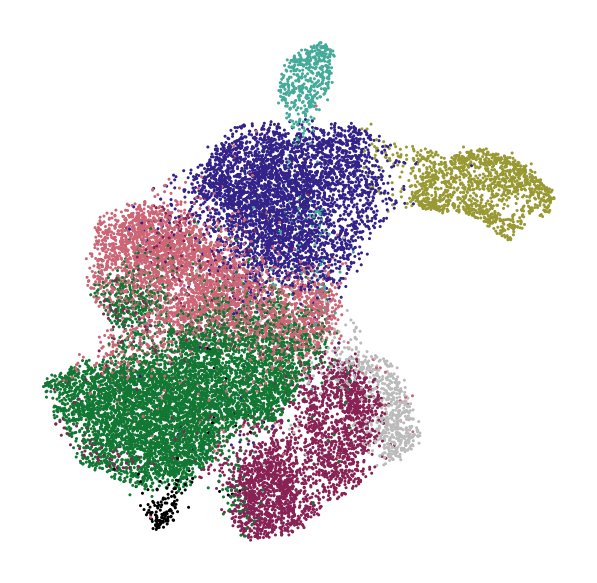

In [5]:
sc.set_figure_params(dpi=90)
sc.pp.neighbors(CD8, n_pcs=35)
sc.tl.umap(CD8)
sc.pl.umap(CD8, color=['Annotation'], legend_loc='', frameon=False,
           legend_fontsize=8, title='', palette=CD8palette)

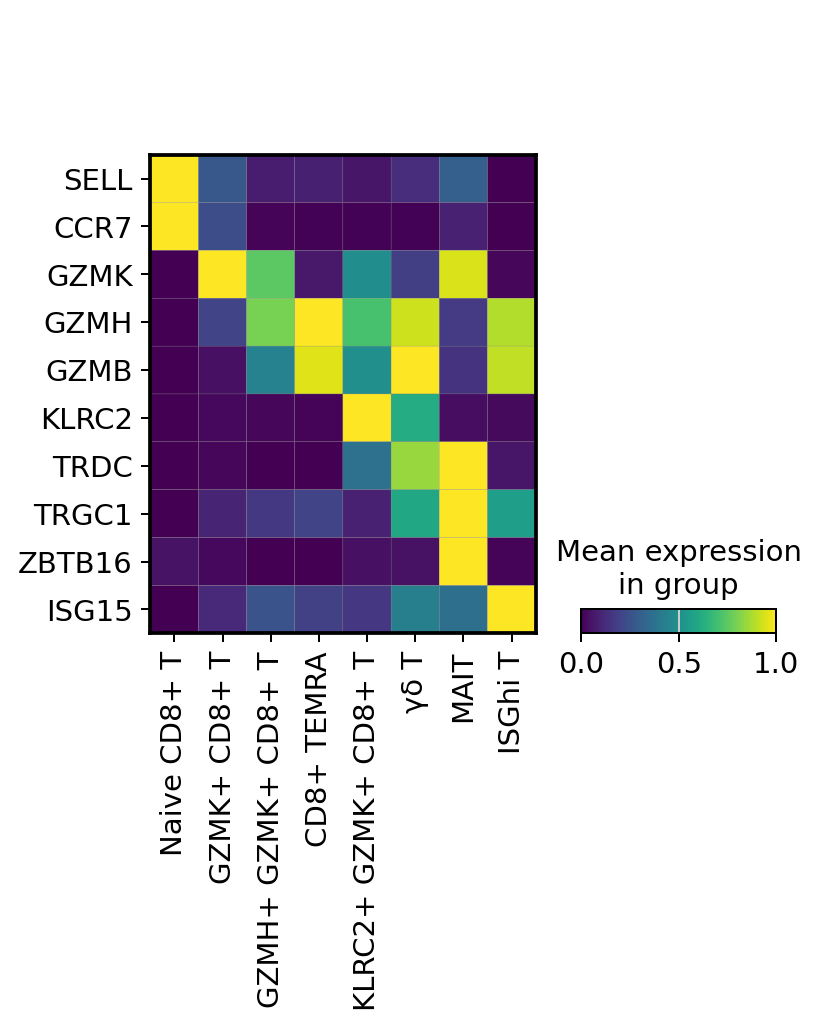

In [6]:
sc.set_figure_params(dpi=90)

new_order = [
    'Naive CD8+ T', 'GZMK+ CD8+ T', 'GZMH+ GZMK+ CD8+ T',
    'CD8+ TEMRA', 'KLRC2+ GZMK+ CD8+ T', 'γδ T', 'MAIT', 'ISGhi T',
]

CD8.obs['Annotation'] = CD8.obs['Annotation'].astype('category').cat.reorder_categories(new_order, ordered=True)

sc.pl.matrixplot(
    CD8,
    ['SELL', 'CCR7', 'GZMK', 'GZMH', 'GZMB', 'KLRC2', 'TRDC', 'TRGC1', 'ZBTB16', 'ISG15'],
    groupby=['Annotation'],
    standard_scale='var',
    swap_axes=True,
)

## Figure 4b

In [49]:
files = glob.glob("/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Annotation/DE_*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    df['source'] = os.path.splitext(os.path.basename(f))[0].split("DE_", 1)[1]
    dfs.append(df)

degs = pd.concat(dfs, ignore_index=True)
degs.rename(columns={"Unnamed: 0": "Gene"}, inplace=True)

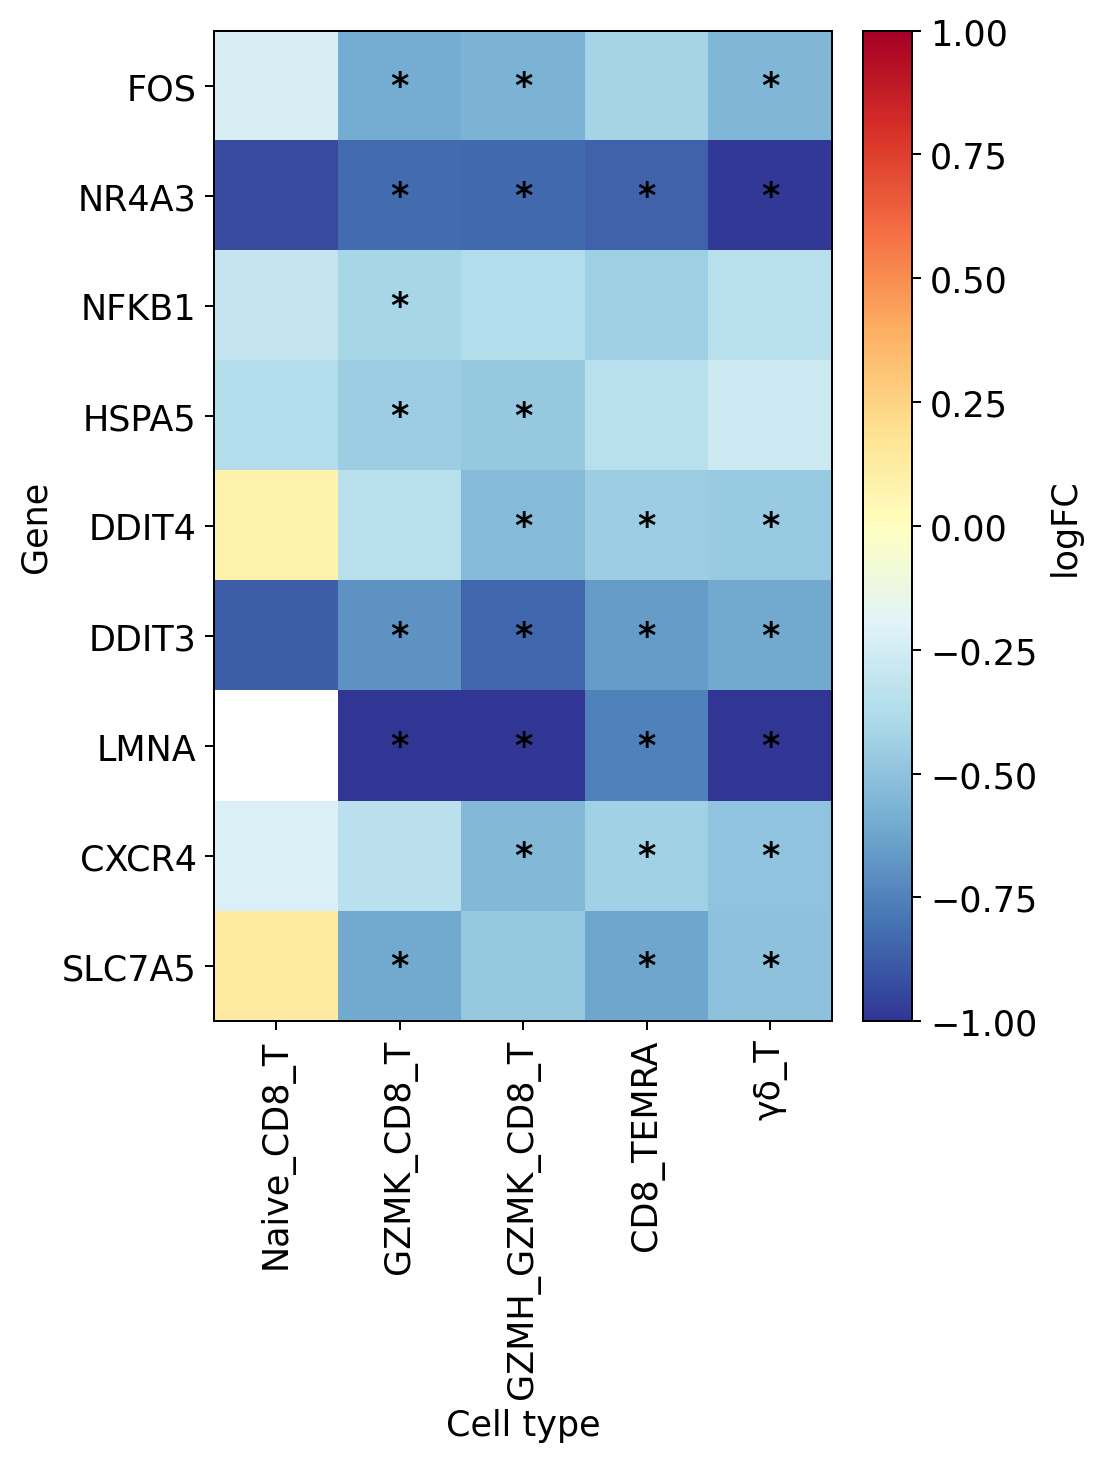

In [52]:
gene_order = ['FOS', 'NR4A3', 'NFKB1', 'HSPA5', 'DDIT4', 'DDIT3', 'LMNA', 'CXCR4', 'SLC7A5']

heatmap_data = (
    degs
    .pivot(index='Gene', columns='source', values='logFC')
    .reindex(index=gene_order, columns=["Naive_CD8_T", "GZMK_CD8_T", "GZMH_GZMK_CD8_T", "CD8_TEMRA", "γδ_T"])
)

padj = (
    degs
    .pivot(index='Gene', columns='source', values='FDR')
    .reindex(index=gene_order, columns=heatmap_data.columns)
)
sig_mask = (padj < 0.05) & (heatmap_data.abs() > 0.4)

keep = ~heatmap_data.index.str.startswith("AC")
heatmap_data = heatmap_data.loc[keep]
sig_mask = sig_mask.loc[keep]

fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlBu_r', vmax=1, vmin=-1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('logFC')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=90)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel('Cell type')
ax.set_ylabel('Gene')
ax.grid(False)

for i, gene in enumerate(heatmap_data.index):
    for j, ct in enumerate(heatmap_data.columns):
        if sig_mask.loc[gene, ct]:
            ax.text(j, i, '*', ha='center', va='center', color='black', fontweight='bold')
plt.savefig("/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Figures/Fig4b.pdf", dpi=300, bbox_inches='tight')

## Figure 4c

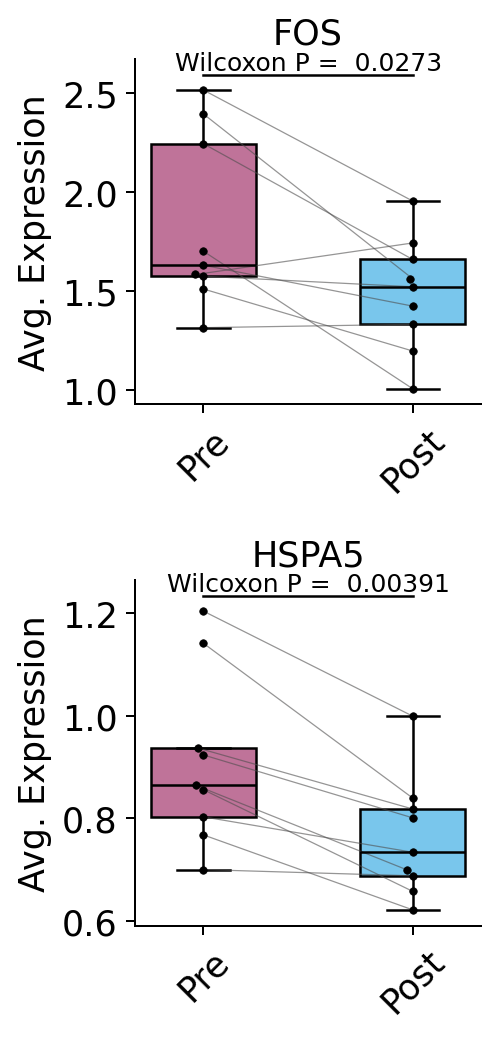

In [54]:
sc.set_figure_params(dpi=90)
gzmk_cd8 = allpbmcs[allpbmcs.obs['Annotation'] == 'GZMK+ CD8+ T'].raw.to_adata().copy()
curfig = plotExpressionMultiple(gzmk_cd8, ['FOS', 'HSPA5'], ncols=1)
curfig.savefig("/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Figures/Fig4c.pdf")

## Figure 4d

In [10]:
deg_gzmkCD8 = pd.read_csv('/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Annotation/DE_GZMK_CD8_T.csv')
deg_gzmkCD8 = deg_gzmkCD8.sort_values(by='FDR', ascending=True)

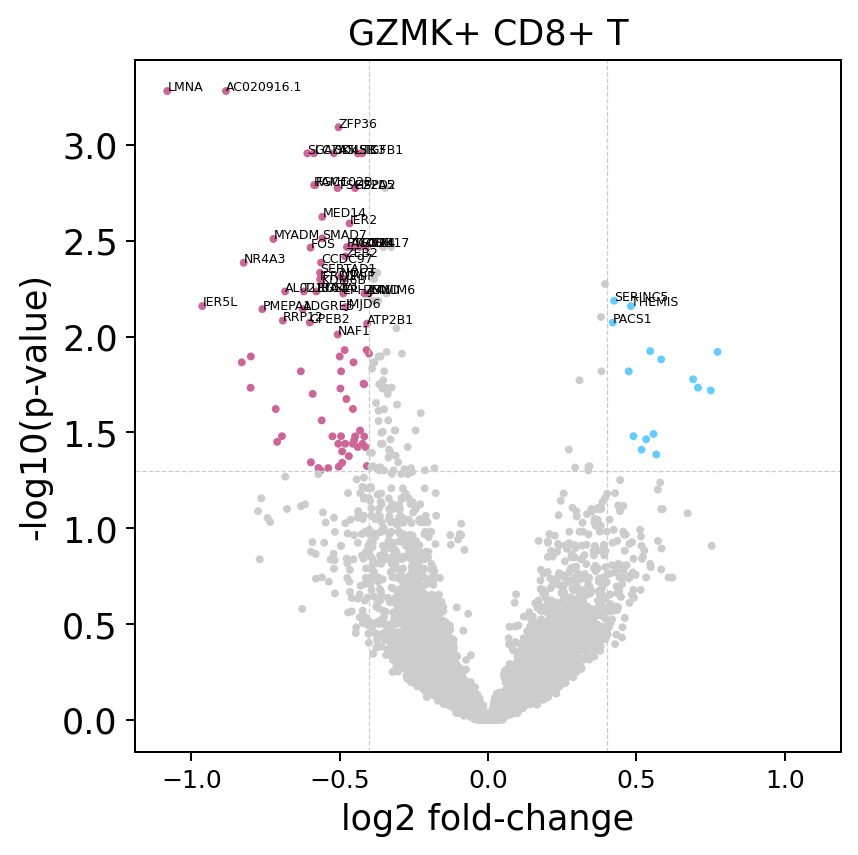

In [11]:
sc.set_figure_params(dpi=90)
fig = plot_volcano(
    deg_gzmkCD8,
    title="GZMK+ CD8+ T",
    logfc=0.4,
    adjustp=0.05,
    label_fc=0.4,
    label_p=0.01,
)
plt.show()

## Figure 4e

In [ ]:
%%R
library(GSEABase)
library(fgsea)
library(msigdb)
library(ggplot2)

msigdb.hs <- getMsigdb(org = "hs", id = "SYM", version = "7.4")
msigdb.hs <- appendKEGG(msigdb.hs)

t_ctype <- lapply(msigdb.hs, GSEABase::collectionType)
t_gsc <- msigdb.hs[
  sapply(t_ctype, GSEABase::bcCategory) %in% "h" |
    sapply(t_ctype, GSEABase::bcSubCategory) %in% c("CP:KEGG", "CP:PID")
]
msigdb_ids <- geneIds(t_gsc)
all_msigdb <- geneIds(msigdb.hs)

exhaust_sets <- c(
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_UP",
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_DN"
)
missing <- setdiff(exhaust_sets, names(all_msigdb))
if (length(missing) > 0) {
  warning("These gene sets were not found in msigdb.hs: ", paste(missing, collapse = ", "))
}
msigdb_exhaust <- all_msigdb[intersect(exhaust_sets, names(all_msigdb))]

sen_genes_df <- read.csv("./Final_Files/GSEA_Signatures/SenMayo.csv")
Sen_Mayo <- list(Sen_Mayo = unique(as.character(sen_genes_df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveCD4_vsOtherCD4_signature.csv")
NaiveCD4 <- list(NaiveCD4 = unique(as.character(df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveB_vsOtherB_signature.csv")
NaiveB <- list(NaiveB = unique(as.character(df$gene)))
all_pathways <- c(msigdb_ids, msigdb_exhaust, Sen_Mayo, NaiveCD4, NaiveB)

degeneresult <- read.csv('./Final_Files/DEG_Results/Annotation/DE_GZMK_CD8_T.csv', stringsAsFactors = FALSE)
degeneresult <- degeneresult[!duplicated(degeneresult$X), ]
degeneresult$PValue <- suppressWarnings(as.numeric(degeneresult$PValue))
degeneresult$logFC <- suppressWarnings(as.numeric(degeneresult$logFC))
degeneresult <- degeneresult[!is.na(degeneresult$PValue) & !is.na(degeneresult$logFC), ]
degeneresult$PValue[degeneresult$PValue <= 0] <- 1e-300
degeneresult$Score <- -log(degeneresult$PValue) * sign(degeneresult$logFC)
degeneresult <- degeneresult[is.finite(degeneresult$Score), ]
de_ordered <- degeneresult[order(degeneresult$Score, decreasing = TRUE), ]
de_ordered_genes <- setNames(de_ordered$Score, de_ordered$X)

set.seed(929)
fgsea_res <- fgseaMultilevel(pathways = all_pathways, stats = de_ordered_genes)

fgsea_res$leadingEdge <- sapply(fgsea_res$leadingEdge, paste, collapse = ",")
fgseaRes_sorted <- fgsea_res %>% arrange(padj)
head(fgseaRes_sorted, 50)

fgseaRes_sorted <- fgsea_res %>% arrange(NES)
head(fgseaRes_sorted, 50)

print(fgsea_res[fgsea_res$pathway == "HALLMARK_TNFA_SIGNALING_VIA_NFKB", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_TNFA_SIGNALING_VIA_NFKB"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

print(fgsea_res[fgsea_res$pathway == "HALLMARK_UNFOLDED_PROTEIN_RESPONSE", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_UNFOLDED_PROTEIN_RESPONSE"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_UNFOLDED_PROTEIN_RESPONSE",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

## Figure 4f

In [ ]:
library(edgeR)
library(sva)
library(readxl)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(RColorBrewer)

metadata_all <- as.data.frame(read_xlsx("./Final_Files/Table1_Metadata.xlsx"))
colnames(metadata_all)[colnames(metadata_all) == "Sample ID"] <- "SampleID"

gene_panel <- c(
  "ZFP36", "GADD45B", "DUSP2", "IER2", "TNFAIP3", "PTGER4", "FOSB", "FOS",
  "NR4A3", "KDM6B", "PMEPA1", "ATP2B1", "JUNB", "BIRC2", "BTG2", "REL",
  "SLC7A5", "HSPA5", "CNOT2", "ZBTB17", "DNAJC3", "ATF3", "EIF2AK3",
  "DDIT4", "EIF4A2", "MTHFD2", "SLC1A4", "CALR", "FUS", "EIF4A1",
  "EIF4A3", "XBP1"
)

file_name <- "./Final_Files/Pseudobulk/Annotation/GZMK_CD8_T.csv"
sample_name <- tools::file_path_sans_ext(basename(file_name))

pseudobulk <- read.csv(
  file_name,
  row.names = 1,
  check.names = FALSE
)

pseudobulk <- pseudobulk[, colSums(pseudobulk) > 0, drop = FALSE]

metadata <- metadata_all[match(colnames(pseudobulk), metadata_all$SampleID), , drop = FALSE]

if (any(is.na(metadata$SampleID))) {
  missing_samples <- colnames(pseudobulk)[is.na(metadata$SampleID)]
  stop(
    paste0(
      "Metadata missing for samples in ",
      sample_name,
      ": ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

stopifnot(identical(metadata$SampleID, colnames(pseudobulk)))

metadata$Condition <- factor(metadata$Group, levels = c("Pre", "Post"))
metadata$Pair <- factor(metadata$Pair)
metadata$Batch <- factor(metadata$Batch)
rownames(metadata) <- metadata$SampleID

if (nlevels(droplevels(metadata$Condition)) < 2) {
  stop("Only one condition present after subsetting.")
}

if (nlevels(droplevels(metadata$Pair)) < 2) {
  stop("Fewer than 2 pairs present after subsetting.")
}

y <- DGEList(counts = pseudobulk)
y <- calcNormFactors(y)

logcpm_mat <- cpm(y, log = TRUE, prior.count = 1)

batch <- droplevels(metadata$Pair)

if (nlevels(batch) >= 2) {
  logcpm_corrected <- ComBat(
    dat = as.matrix(logcpm_mat),
    batch = batch,
    par.prior = TRUE,
    prior.plots = FALSE
  )
} else {
  logcpm_corrected <- as.matrix(logcpm_mat)
}

present_genes <- gene_panel[gene_panel %in% rownames(logcpm_corrected)]

if (length(present_genes) == 0) {
  stop("None of the requested genes are present in the count matrix.")
}

mat_scaled <- t(scale(t(logcpm_corrected[present_genes, , drop = FALSE])))
mat_scaled[is.na(mat_scaled)] <- 0
mat_scaled[mat_scaled > 2] <- 2
mat_scaled[mat_scaled < -2] <- -2
mat_scaled <- mat_scaled[present_genes, , drop = FALSE]

metadata_plot <- metadata[colnames(mat_scaled), , drop = FALSE]

if (any(is.na(metadata_plot$SampleID))) {
  missing_samples <- colnames(mat_scaled)[is.na(metadata_plot$SampleID)]
  stop(
    paste0(
      "Metadata missing during heatmap ordering for: ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

metadata_plot$Condition <- factor(metadata_plot$Condition, levels = c("Pre", "Post"))
metadata_plot$Pair <- droplevels(metadata_plot$Pair)

ord <- order(metadata_plot$Condition, metadata_plot$Pair)

mat_scaled <- mat_scaled[, ord, drop = FALSE]
metadata_plot <- metadata_plot[ord, , drop = FALSE]

top_anno <- HeatmapAnnotation(
  Condition = metadata_plot$Condition,
  col = list(
    Condition = c(
      Pre = "#CC6699",
      Post = "#66CCFF"
    )
  ),
  show_annotation_name = FALSE,
  show_legend = FALSE,
  simple_anno_size = unit(4, "mm"),
  border = FALSE
)

rdylbu_r <- rev(brewer.pal(11, "RdYlBu"))

col_fun <- colorRamp2(
  seq(-2, 2, length.out = 101),
  colorRampPalette(rdylbu_r)(101)
)

ht <- Heatmap(
  mat_scaled,
  name = "Corrected log2CPM Z-Score",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  cluster_column_slices = FALSE,
  column_split = metadata_plot$Condition,
  column_gap = unit(2, "mm"),
  top_annotation = top_anno,
  show_column_names = FALSE,
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 16, fontface = "italic"),
  row_names_max_width = max_text_width(
    rownames(mat_scaled),
    gp = gpar(fontsize = 16, fontface = "italic")
  ) + unit(2, "mm"),
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  border = FALSE,
  column_title = NULL,
  heatmap_legend_param = list(
    at = c(-2, -1, 0, 1, 2),
    direction = "horizontal",
    title_position = "topcenter",
    legend_width = unit(8, "cm"),
    labels_gp = gpar(fontsize = 12),
    title_gp = gpar(fontsize = 16)
  )
)


gene_panel <- c(
  "DUSP2", "ATP2B1", "PPP1R15A", "JUN", "IER2", "PDE4B", "NR4A3", "BIRC2",
  "ZFP36", "BTG2", "KDM6B", "REL", "PER1", "BHLHE40", "FOSL2", "NFKB1",
  "DDIT4", "HSPA5", "SLC7A5", "CNOT2", "DNAJC3", "ZBTB17", "EIF4A1",
  "EIF4EBP1", "YWHAZ", "SHC1", "SLC1A4", "TUBB2A", "EIF4G1", "PAIP1",
  "LSM1", "EIF4A2"
)

file_name <- "./Final_Files/Pseudobulk/Annotation/CD8_TEMRA.csv"
sample_name <- tools::file_path_sans_ext(basename(file_name))

pseudobulk <- read.csv(
  file_name,
  row.names = 1,
  check.names = FALSE
)

pseudobulk <- pseudobulk[, colSums(pseudobulk) > 0, drop = FALSE]

metadata <- metadata_all[match(colnames(pseudobulk), metadata_all$SampleID), , drop = FALSE]

if (any(is.na(metadata$SampleID))) {
  missing_samples <- colnames(pseudobulk)[is.na(metadata$SampleID)]
  stop(
    paste0(
      "Metadata missing for samples in ",
      sample_name,
      ": ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

stopifnot(identical(metadata$SampleID, colnames(pseudobulk)))

metadata$Condition <- factor(metadata$Group, levels = c("Pre", "Post"))
metadata$Pair <- factor(metadata$Pair)
metadata$Batch <- factor(metadata$Batch)
rownames(metadata) <- metadata$SampleID

if (nlevels(droplevels(metadata$Condition)) < 2) {
  stop("Only one condition present after subsetting.")
}

if (nlevels(droplevels(metadata$Pair)) < 2) {
  stop("Fewer than 2 pairs present after subsetting.")
}

y <- DGEList(counts = pseudobulk)
y <- calcNormFactors(y)

logcpm_mat <- cpm(y, log = TRUE, prior.count = 1)

batch <- droplevels(metadata$Pair)

if (nlevels(batch) >= 2) {
  logcpm_corrected <- ComBat(
    dat = as.matrix(logcpm_mat),
    batch = batch,
    par.prior = TRUE,
    prior.plots = FALSE
  )
} else {
  logcpm_corrected <- as.matrix(logcpm_mat)
}

present_genes <- gene_panel[gene_panel %in% rownames(logcpm_corrected)]

if (length(present_genes) == 0) {
  stop("None of the requested genes are present in the count matrix.")
}

mat_scaled <- t(scale(t(logcpm_corrected[present_genes, , drop = FALSE])))
mat_scaled[is.na(mat_scaled)] <- 0
mat_scaled[mat_scaled > 2] <- 2
mat_scaled[mat_scaled < -2] <- -2
mat_scaled <- mat_scaled[present_genes, , drop = FALSE]

metadata_plot <- metadata[colnames(mat_scaled), , drop = FALSE]

if (any(is.na(metadata_plot$SampleID))) {
  missing_samples <- colnames(mat_scaled)[is.na(metadata_plot$SampleID)]
  stop(
    paste0(
      "Metadata missing during heatmap ordering for: ",
      paste(missing_samples, collapse = ", ")
    )
  )
}

metadata_plot$Condition <- factor(metadata_plot$Condition, levels = c("Pre", "Post"))
metadata_plot$Pair <- droplevels(metadata_plot$Pair)

ord <- order(metadata_plot$Condition, metadata_plot$Pair)

mat_scaled <- mat_scaled[, ord, drop = FALSE]
metadata_plot <- metadata_plot[ord, , drop = FALSE]

top_anno <- HeatmapAnnotation(
  Condition = metadata_plot$Condition,
  col = list(
    Condition = c(
      Pre = "#CC6699",
      Post = "#66CCFF"
    )
  ),
  show_annotation_name = FALSE,
  show_legend = FALSE,
  simple_anno_size = unit(4, "mm"),
  border = FALSE
)

rdylbu_r <- rev(brewer.pal(11, "RdYlBu"))

col_fun <- colorRamp2(
  seq(-2, 2, length.out = 101),
  colorRampPalette(rdylbu_r)(101)
)

ht <- Heatmap(
  mat_scaled,
  name = "Corrected log2CPM Z-Score",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  cluster_column_slices = FALSE,
  column_split = metadata_plot$Condition,
  column_gap = unit(2, "mm"),
  top_annotation = top_anno,
  show_column_names = FALSE,
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 16, fontface = "italic"),
  row_names_max_width = max_text_width(
    rownames(mat_scaled),
    gp = gpar(fontsize = 16, fontface = "italic")
  ) + unit(2, "mm"),
  show_row_dend = FALSE,
  show_column_dend = FALSE,
  border = FALSE,
  column_title = NULL,
  heatmap_legend_param = list(
    at = c(-2, -1, 0, 1, 2),
    direction = "horizontal",
    title_position = "topcenter",
    legend_width = unit(8, "cm"),
    labels_gp = gpar(fontsize = 12),
    title_gp = gpar(fontsize = 16)
  )
)

## Figure 4g

In [12]:
NK = allpbmcs[allpbmcs.obs['Annotation'].isin(['CD56dim NK', 'CD56bright NK', 'Adaptive NK'])].copy()
NK

AnnData object with n_obs × n_vars = 14130 × 31720
    obs: 'SampleID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Annotation', 'Lineage Annotation', 'Group', 'Sex', 'Age', 'Ancestry', 'Body Mass Index (BMI)', 'Total Mass (kg)', 'Lean Mass (kg)', 'Fat Mass (kg)', 'VO2 (mL/kg/min)', 'PPT', 'HBA1C (%)', 'HOMA-IR', 'MATSUDA index', 'RKE60', 'Triglyceride (mg/dL)', 'C-reactive protein', 'ROS byproduct - Isoprostane (pg/mL)', 'Batch'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'Annotatation_colors', 'Batch_colors', 'Final_GroupAnnotation_colors', 'Final_annotation_v2_colors', 'Final_annotation_v2_revised_colors', 'GroupAnnotation_colors', 'Lineage Annotation_colors', 'OldAnnotations_colors', 'SampleID_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_col

In [13]:
sc.pp.neighbors(NK, n_pcs=20)
sc.tl.umap(NK)

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


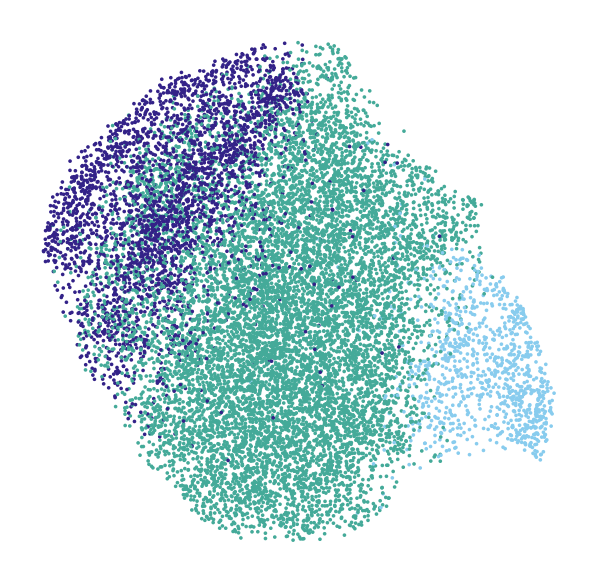

In [14]:
sc.set_figure_params(dpi=90)

NKpalette = {
    'CD56bright NK':  '#88CCEE',
    'CD56dim NK':     '#44AA99',
    'Adaptive NK':    '#332288',
    'Proliferating NK': '#000000',
}

sc.pl.umap(NK, color=['Annotation'], frameon=False, legend_fontsize=14,
           title='', palette=NKpalette, legend_loc='')

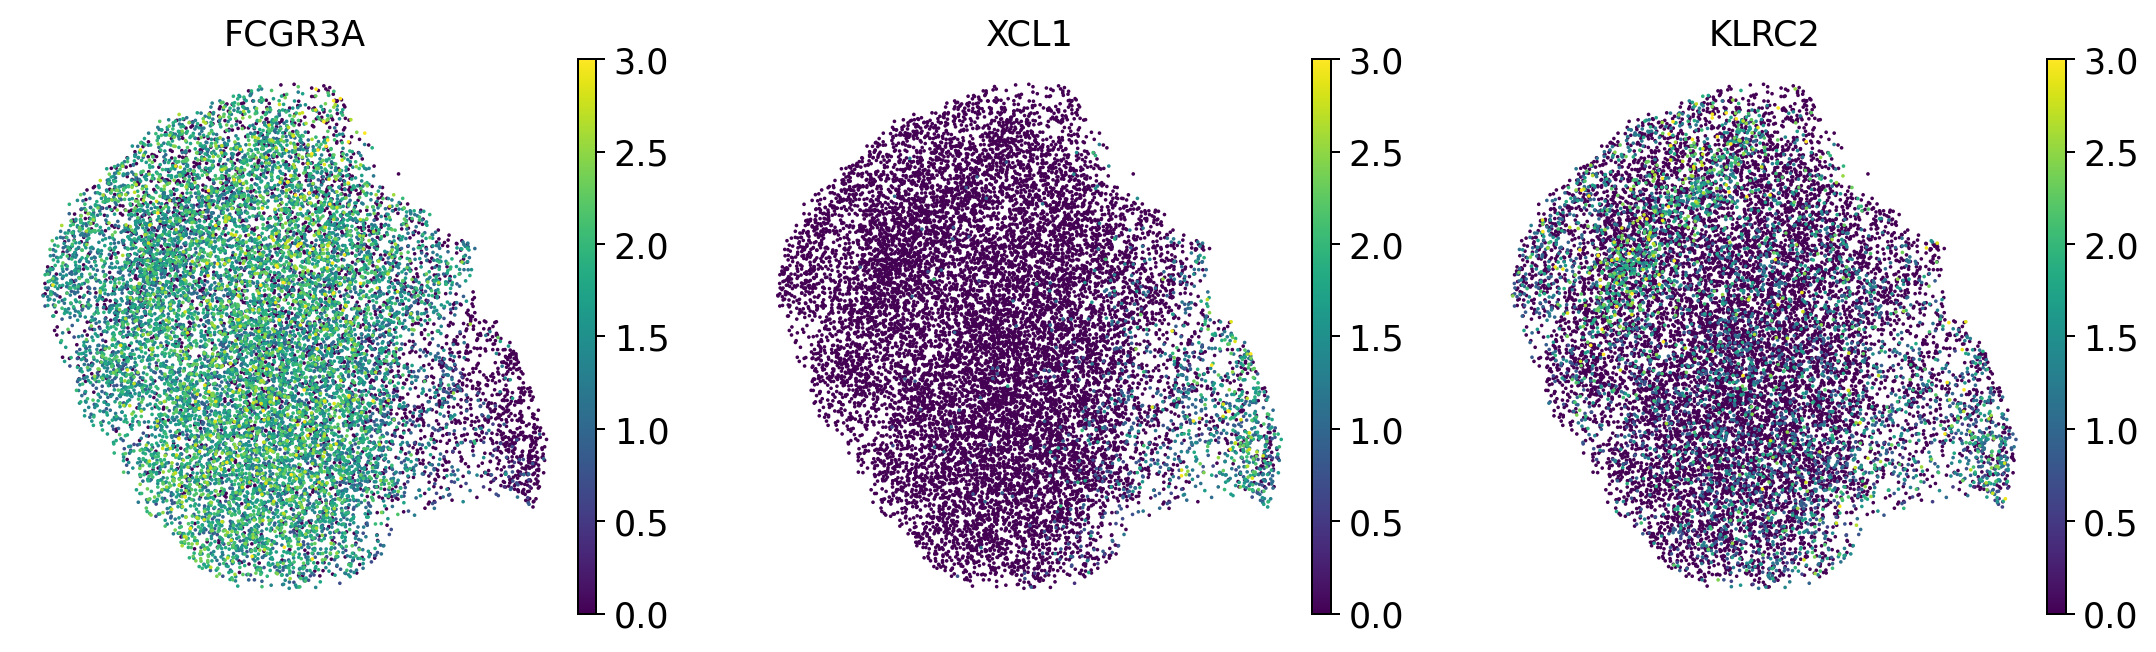

In [15]:
sc.set_figure_params(dpi=90)
sc.pl.umap(NK, color=['FCGR3A', 'XCL1', 'KLRC2'],
           frameon=False, ncols=3, cmap='viridis', vmax=3)

## Figure 4h

In [16]:
deg_cd56dim = pd.read_csv('/projects/USERS/yerrar/Lifestyle2024/scLifestyle_PREvPOST/Final_Files/DEG_Results/Annotation/DE_CD56dim_NK.csv')
deg_cd56dim = deg_cd56dim.sort_values(by='FDR', ascending=True)

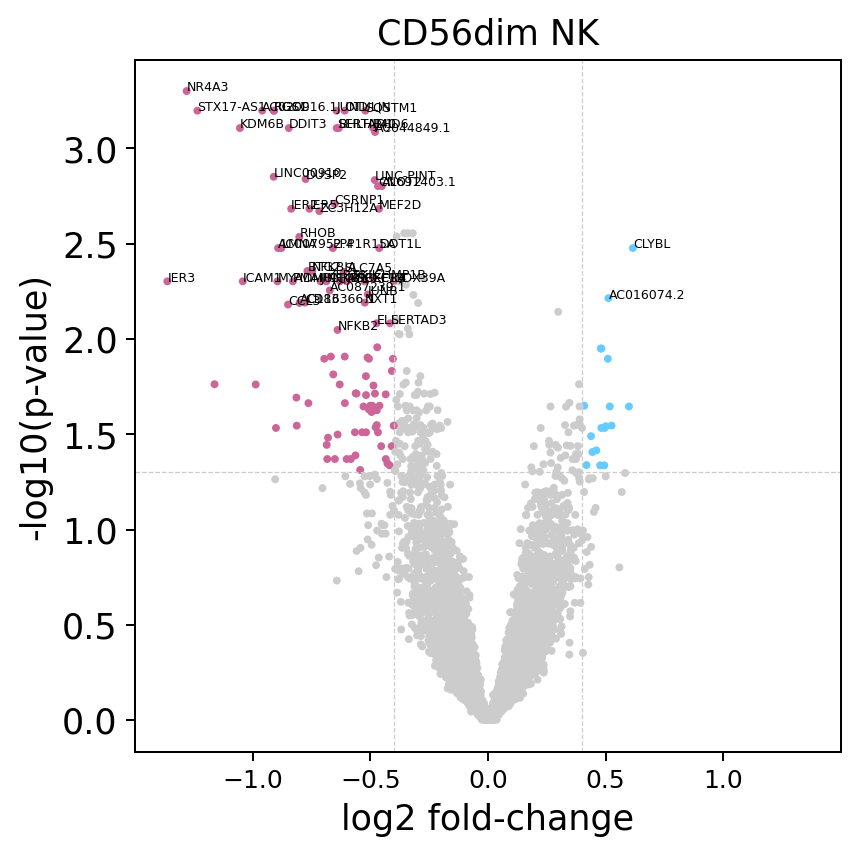

In [17]:
sc.set_figure_params(dpi=90)
fig = plot_volcano(
    deg_cd56dim,
    title="CD56dim NK",
    logfc=0.4,
    adjustp=0.05,
    label_fc=0.4,
    label_p=0.01,
)
plt.show()

## Figure 4i

In [ ]:
%%R
library(GSEABase)
library(fgsea)
library(msigdb)
library(ggplot2)

msigdb.hs <- getMsigdb(org = "hs", id = "SYM", version = "7.4")
msigdb.hs <- appendKEGG(msigdb.hs)

t_ctype <- lapply(msigdb.hs, GSEABase::collectionType)
t_gsc <- msigdb.hs[
  sapply(t_ctype, GSEABase::bcCategory) %in% "h" |
    sapply(t_ctype, GSEABase::bcSubCategory) %in% c("CP:KEGG", "CP:PID")
]
msigdb_ids <- geneIds(t_gsc)
all_msigdb <- geneIds(msigdb.hs)

exhaust_sets <- c(
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_UP",
  "GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_DN"
)
missing <- setdiff(exhaust_sets, names(all_msigdb))
if (length(missing) > 0) {
  warning("These gene sets were not found in msigdb.hs: ", paste(missing, collapse = ", "))
}
msigdb_exhaust <- all_msigdb[intersect(exhaust_sets, names(all_msigdb))]

sen_genes_df <- read.csv("./Final_Files/GSEA_Signatures/SenMayo.csv")
Sen_Mayo <- list(Sen_Mayo = unique(as.character(sen_genes_df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveCD4_vsOtherCD4_signature.csv")
NaiveCD4 <- list(NaiveCD4 = unique(as.character(df$gene)))
df <- read.csv("./Final_Files/GSEA_Signatures/NaiveB_vsOtherB_signature.csv")
NaiveB <- list(NaiveB = unique(as.character(df$gene)))
all_pathways <- c(msigdb_ids, msigdb_exhaust, Sen_Mayo, NaiveCD4, NaiveB)

degeneresult <- read.csv('./Final_Files/DEG_Results/Annotation/DE_CD56dim_NK.csv', stringsAsFactors = FALSE)
degeneresult <- degeneresult[!duplicated(degeneresult$X), ]
degeneresult$PValue <- suppressWarnings(as.numeric(degeneresult$PValue))
degeneresult$logFC <- suppressWarnings(as.numeric(degeneresult$logFC))
degeneresult <- degeneresult[!is.na(degeneresult$PValue) & !is.na(degeneresult$logFC), ]
degeneresult$PValue[degeneresult$PValue <= 0] <- 1e-300
degeneresult$Score <- -log(degeneresult$PValue) * sign(degeneresult$logFC)
degeneresult <- degeneresult[is.finite(degeneresult$Score), ]
de_ordered <- degeneresult[order(degeneresult$Score, decreasing = TRUE), ]
de_ordered_genes <- setNames(de_ordered$Score, de_ordered$X)

set.seed(929)
fgsea_res <- fgseaMultilevel(pathways = all_pathways, stats = de_ordered_genes)

fgsea_res$leadingEdge <- sapply(fgsea_res$leadingEdge, paste, collapse = ",")
fgseaRes_sorted <- fgsea_res %>% arrange(padj)
head(fgseaRes_sorted, 50)

fgseaRes_sorted <- fgsea_res %>% arrange(NES)
head(fgseaRes_sorted, 50)

print(fgsea_res[fgsea_res$pathway == "HALLMARK_TNFA_SIGNALING_VIA_NFKB", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_TNFA_SIGNALING_VIA_NFKB"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

print(fgsea_res[fgsea_res$pathway == "HALLMARK_APOPTOSIS", ])
p_1 <- plotEnrichment(
  pathway = all_pathways[["HALLMARK_APOPTOSIS"]],
  stats   = de_ordered_genes
) +
  labs(
    title = "GSEA: HALLMARK_APOPTOSIS",
    x     = "Ranked genes",
    y     = "Enrichment Score"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(face="bold", size=16),
    plot.subtitle = element_text(size=12, color="grey30"),
    axis.text     = element_text(color="black"),
    plot.caption  = element_text(size=8, hjust=0)
  )

## Figure 4j

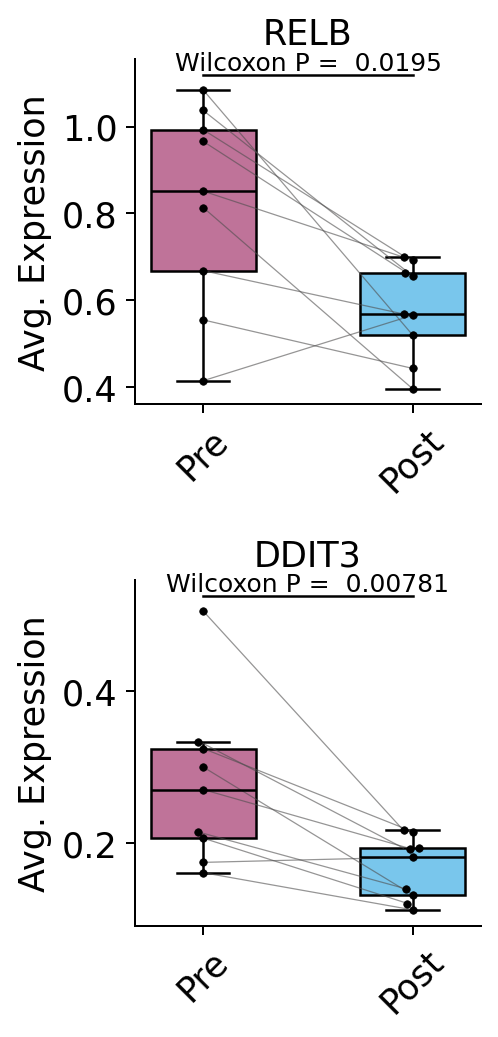

In [18]:
sc.set_figure_params(dpi=90)

cd56dim_nk = allpbmcs[allpbmcs.obs['Annotation'] == 'CD56dim NK'].raw.to_adata().copy()
curfig = plotExpressionMultiple(cd56dim_nk, ['RELB', 'DDIT3'], ncols=1)